In [1]:
from rdkit import Chem

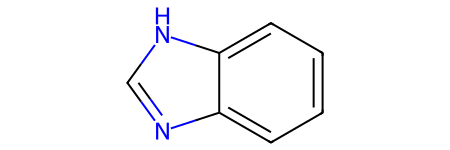

In [2]:
Chem.MolFromSmiles('c1nc2ccccc2[nH]1')

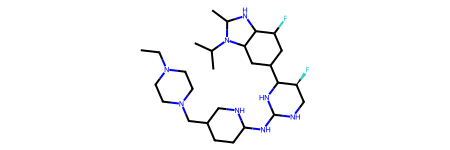

In [5]:
mol = Chem.MolFromPDBFile('CDK6_workflow/grid/5L2S_ligand.pdb')
Chem.MolFromSmiles(Chem.MolToSmiles(mol))

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

# Read the CDK2 data
df_cdk2 = pl.read_csv('CDK2_workflow/CHEMBL2508_raw_data.csv')

# Filter for IC50 values and convert to numeric
ic50_data = df_cdk2.filter(pl.col('standard_type') == 'IC50')

# Plot distribution
plt.figure(figsize=(10, 6))
plt.hist(ic50_data['standard_value'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('IC50 (nM)')
plt.ylabel('Frequency')
plt.title('Distribution of IC50 Values for CDK2 (CHEMBL2508)')
plt.grid(True, alpha=0.3)
plt.show()

# Print summary statistics
print(f"Number of IC50 values: {len(ic50_data)}")
print(f"Mean IC50: {ic50_data['standard_value'].mean():.2f} nM")
print(f"Median IC50: {ic50_data['standard_value'].median():.2f} nM")
print(f"Min IC50: {ic50_data['standard_value'].min():.2f} nM")
print(f"Max IC50: {ic50_data['standard_value'].max():.2f} nM")

In [ ]:
import polars as pl
from chembl_webresource_client.new_client import new_client

# ---------------------------------------------------------
# INPUTS
# ---------------------------------------------------------
target_id = "CHEMBL301"       # CDK2
document_id = "CHEMBL5728430" # Example Patent/Paper ID

# ---------------------------------------------------------
# 1. Fetch Data
# ---------------------------------------------------------
activity = new_client.activity

print(f"Fetching data for Target: {target_id} in Document: {document_id}...")

# Note: The API returns a "QuerySet". We must convert it to a list
# of dictionaries so Polars can ingest it.
results = activity.filter(
    target_chembl_id=target_id,
    document_chembl_id=document_id
)

data_list = list(results)

if data_list:
    # ---------------------------------------------------------
    # 2. Create Polars DataFrame
    # infer_schema_length=None scans all rows to ensure no columns are missed
    # if the API returns sparse data (keys missing in some rows).
    # ---------------------------------------------------------
    df = pl.from_dicts(data_list, infer_schema_length=None)

    # ---------------------------------------------------------
    # 3. Clean and Select Columns
    # ---------------------------------------------------------
    columns_to_keep = [
        'molecule_chembl_id', 
        'standard_type', 
        'standard_relation', 
        'standard_value', 
        'standard_units', 
        'canonical_smiles',
        'assay_type'
    ]

    # Filter the list to only include columns that actually exist in the response
    available_cols = [c for c in columns_to_keep if c in df.columns]
    
    # Polars uses .select() rather than bracket indexing for column subsets
    clean_df = df.select(available_cols)

    # Optional: Cast standard_value to Float (API returns strings)
    # We use strict=False to turn non-numeric strings into nulls
    if 'standard_value' in clean_df.columns:
        clean_df = clean_df.with_columns(
            pl.col("standard_value").cast(pl.Float64, strict=False)
        )

    print(f"Found {len(clean_df)} bioactivity records.")
    print(clean_df.head())

    # Save to CSV
    # clean_df.write_csv("chembl_extraction.csv")

else:
    print("No bioactivity data found for this combination.")

Fetching data for Target: CHEMBL301 in Document: CHEMBL5728430...
Found 432 bioactivity records.
shape: (5, 7)
┌──────────────┬──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬────────────┐
│ molecule_che ┆ standard_typ ┆ standard_re ┆ standard_va ┆ standard_un ┆ canonical_s ┆ assay_type │
│ mbl_id       ┆ e            ┆ lation      ┆ lue         ┆ its         ┆ miles       ┆ ---        │
│ ---          ┆ ---          ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ str        │
│ str          ┆ str          ┆ str         ┆ f64         ┆ str         ┆ str         ┆            │
╞══════════════╪══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪════════════╡
│ CHEMBL330161 ┆ IC50         ┆ =           ┆ 52.2        ┆ nM          ┆ CCN1CCN(Cc2 ┆ B          │
│ 0            ┆              ┆             ┆             ┆             ┆ ccc(Nc3ncc( ┆            │
│              ┆              ┆             ┆             ┆             ┆ F)c(-c4

In [2]:
clean_df

molecule_chembl_id,standard_type,standard_relation,standard_value,standard_units,canonical_smiles,assay_type
str,str,str,f64,str,str,str
"""CHEMBL3301610""","""IC50""","""=""",52.2,"""nM""","""CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4c…","""B"""
"""CHEMBL3301610""","""kon""","""=""",null,null,"""CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4c…","""B"""
"""CHEMBL3301610""","""k_off""","""=""",null,"""s-1""","""CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4c…","""B"""
"""CHEMBL5905735""","""IC50""","""=""",35.0,"""nM""","""Cc1nc2c(F)cc(-c3nc(Nc4ccc5c(n4…","""B"""
"""CHEMBL5905735""","""kon""","""=""",null,null,"""Cc1nc2c(F)cc(-c3nc(Nc4ccc5c(n4…","""B"""
…,…,…,…,…,…,…
"""CHEMBL5908734""","""kon""","""=""",null,null,"""Cc1nc2c(F)cc(-c3nc(Nc4ccc5c(n4…","""B"""
"""CHEMBL5908734""","""k_off""","""=""",null,"""s-1""","""Cc1nc2c(F)cc(-c3nc(Nc4ccc5c(n4…","""B"""
"""CHEMBL4207796""","""IC50""","""=""",22.5,"""nM""","""Cc1nc2c(F)cc(-c3nc(Nc4ccc5c(n4…","""B"""


In [3]:
# Count null values in standard_value column
null_count = clean_df.filter(pl.col("standard_value").is_null()).height
total_count = clean_df.height

print(f"Null values in standard_value: {null_count} out of {total_count} ({null_count/total_count*100:.2f}%)")

Null values in standard_value: 288 out of 432 (66.67%)


In [4]:
clean_df.filter(pl.col("standard_value").is_not_null())['standard_relation'].unique()

standard_relation
str
""">"""
"""="""


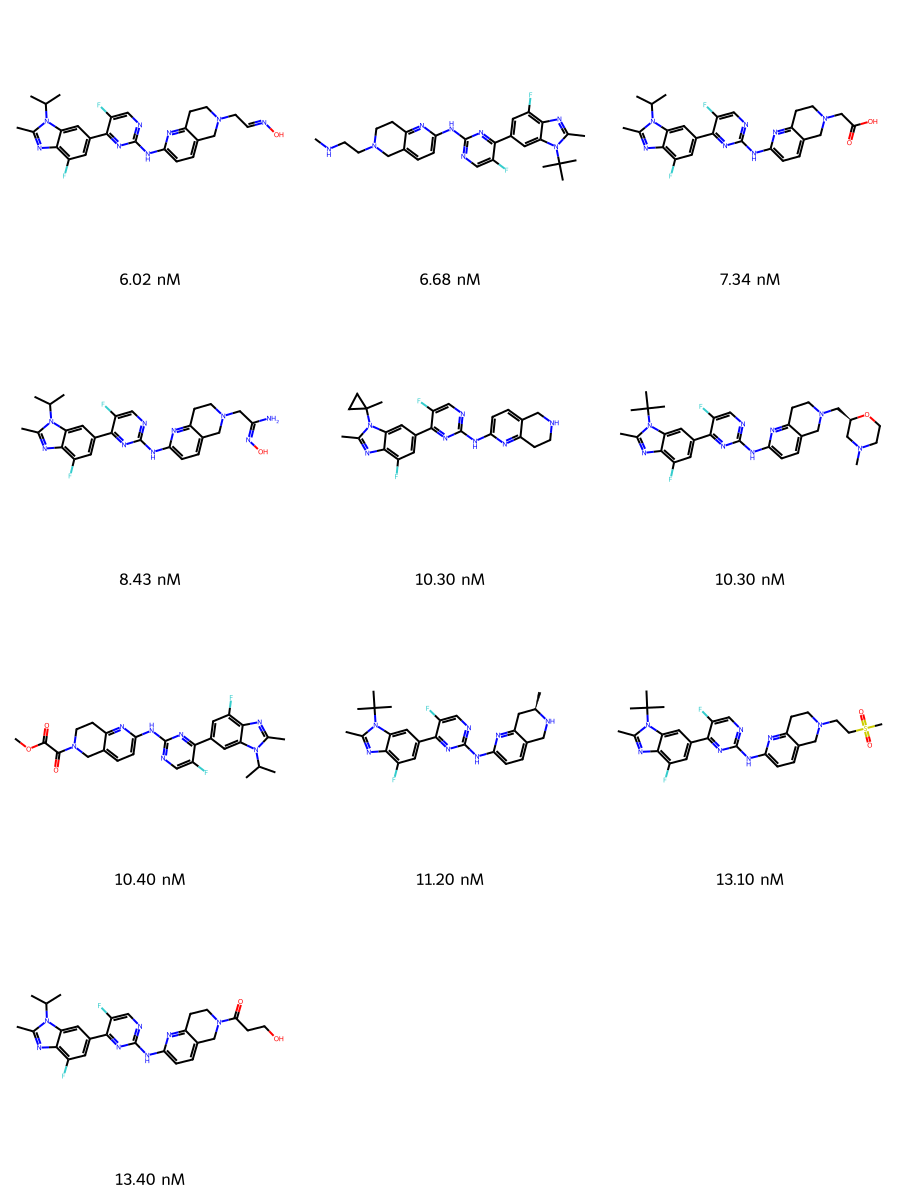

In [5]:
from rdkit import Chem
from rdkit.Chem import Draw

# Get the most potent compounds (lowest standard_value)
most_potent = clean_df.filter(
    pl.col("canonical_smiles").is_not_null() & 
    pl.col("standard_value").is_not_null()
).sort("standard_value").head(10)

# Convert SMILES to RDKit molecule objects
mols = []
legends = []
for row in most_potent.iter_rows(named=True):
    mol = Chem.MolFromSmiles(row["canonical_smiles"])
    if mol is not None:
        mols.append(mol)
        legends.append(f"{row['standard_value']:.2f} {row['standard_units']}")

# Draw the molecules with their potency values
if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300), legends=legends)
    display(img)
else:
    print("No valid molecules to draw")

Number of valid molecules for MCS: 144
MCS SMARTS: [#6&!R]-&!@[#6]1:&@[#7]:&@[#6]2:&@[#6](:&@[#7]:&@1):&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@2)-&!@[#6]1:&@[#7]:&@[#6](-&!@[#7&!R]-&!@[#6&R]:&@[#7&R]:&@[#6&R]:&@[#6&R]:&@[#6&R]:,-;@[#6&R]):&@[#7]:&@[#6]:&@[#6]:&@1-&!@[#9&!R]
Number of atoms in MCS: 24
Number of bonds in MCS: 26


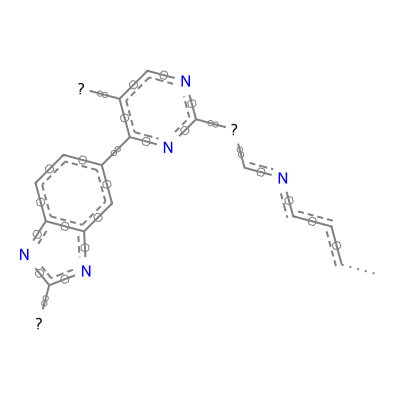

In [6]:
from rdkit.Chem import rdFMCS

# Get molecules with non-null standard_value
valid_df = clean_df.filter(pl.col("standard_value").is_not_null())

# Convert SMILES to RDKit molecule objects
mols_for_mcs = []
for smiles in valid_df["canonical_smiles"]:
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        mols_for_mcs.append(mol)

print(f"Number of valid molecules for MCS: {len(mols_for_mcs)}")

# Find Maximum Common Substructure (MCS)
if len(mols_for_mcs) >= 2:
    mcs_result = rdFMCS.FindMCS(mols_for_mcs, ringMatchesRingOnly=True, timeout=60)
    print(f"MCS SMARTS: {mcs_result.smartsString}")
    print(f"Number of atoms in MCS: {mcs_result.numAtoms}")
    print(f"Number of bonds in MCS: {mcs_result.numBonds}")
    
    # Visualize the MCS
    mcs_mol = Chem.MolFromSmarts(mcs_result.smartsString)
    if mcs_mol is not None:
        img = Draw.MolToImage(mcs_mol, size=(400, 400))
        display(img)
else:
    print("Need at least 2 molecules to find MCS")

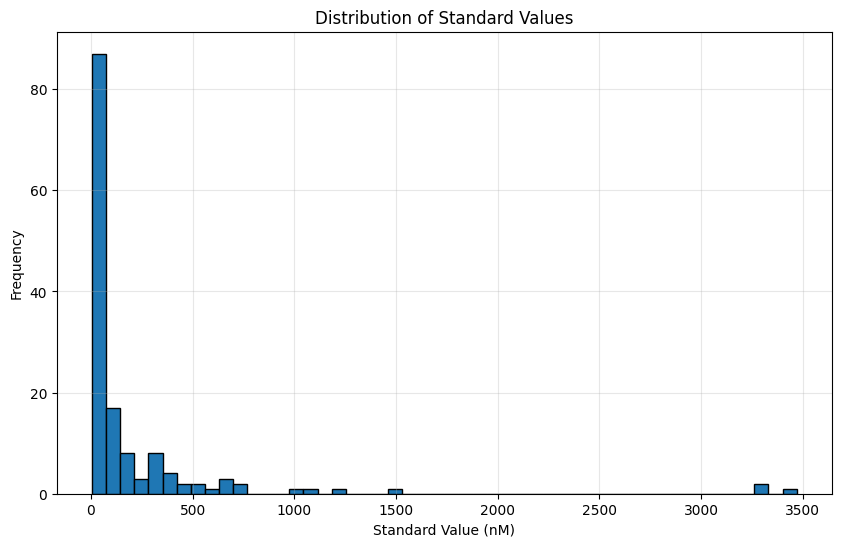

Number of non-null values: 144
Min: 6.02
Max: 3470.0
Mean: 219.64631944444443
Median: 49.349999999999994


In [7]:
import matplotlib.pyplot as plt

# Filter for non-null standard_value
valid_values = clean_df.filter(pl.col("standard_value").is_not_null())

# Plot histogram of standard_value
plt.figure(figsize=(10, 6))
plt.hist(valid_values["standard_value"].to_numpy(), bins=50, edgecolor='black')
plt.xlabel('Standard Value (nM)')
plt.ylabel('Frequency')
plt.title('Distribution of Standard Values')
plt.grid(True, alpha=0.3)
plt.show()

# Also show some statistics
print(f"Number of non-null values: {len(valid_values)}")
print(f"Min: {valid_values['standard_value'].min()}")
print(f"Max: {valid_values['standard_value'].max()}")
print(f"Mean: {valid_values['standard_value'].mean()}")
print(f"Median: {valid_values['standard_value'].median()}")

In [8]:
Chem.MolToSmiles(mcs_mol)

'C:C:C:C:N:CNC1:N:C:C(F):C(C2:C:C:C3:N:C(C):N:C:3:C:2):N:1'

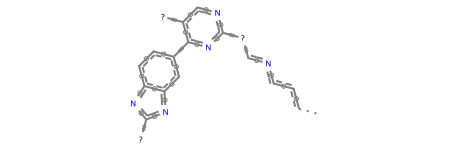

In [9]:
mcs_mol

In [11]:
clean_df.write_csv("chembl_data.csv")